Wine Quality Prediction

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
df = pd.read_csv("WineQT.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [ ]:
print(df.shape)

print(df.info())

print(df.describe())

(1143, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
None
       fixed acidity  volatile acidity  citric acid  residu

Check missing values

In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


Check Wine Quality Distribution

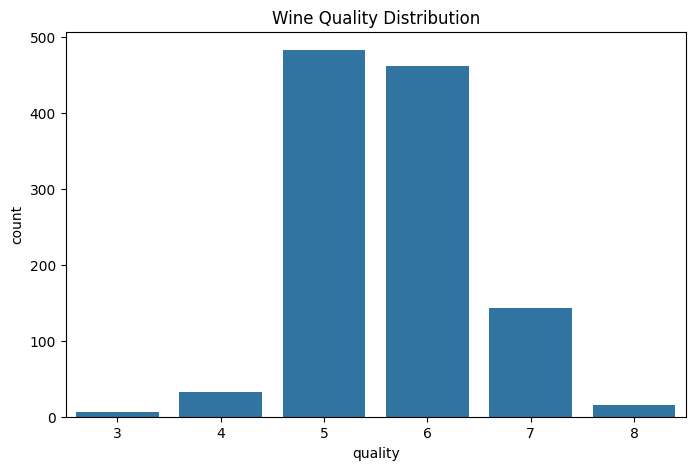

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='quality', data=df)

plt.title("Wine Quality Distribution")

plt.show()

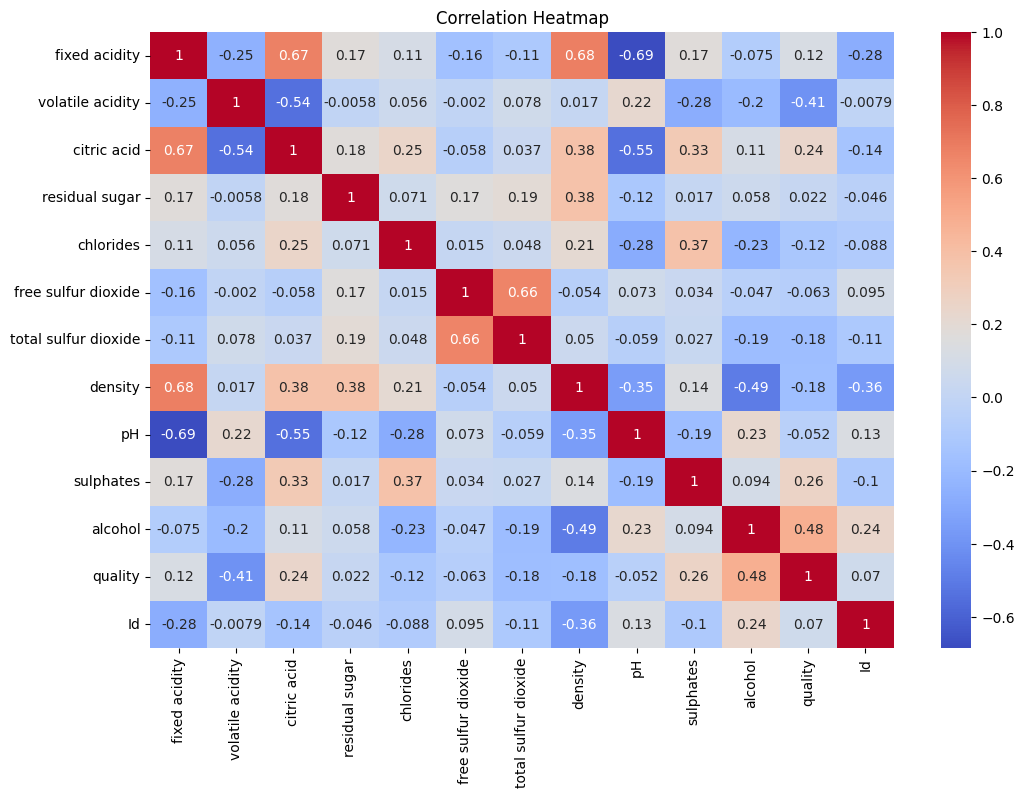

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

Data Visualization

Acidity vs Quality

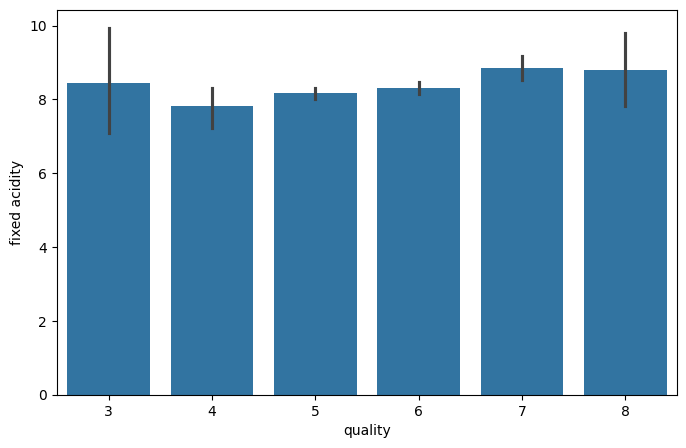

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='quality',
    y='fixed acidity',
    data=df
)

plt.show()

Alcohol vs Quality

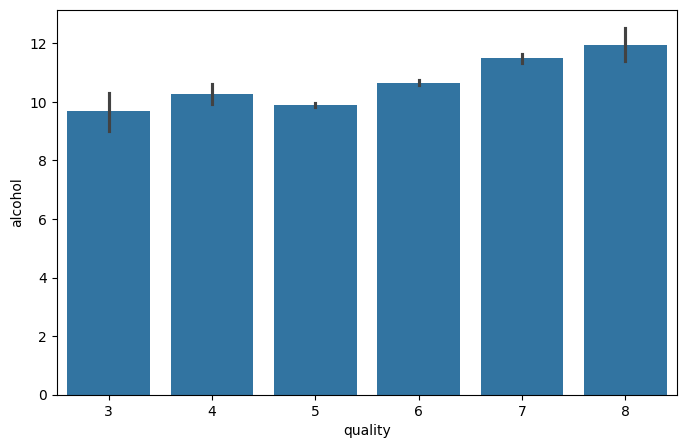

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='quality',
    y='alcohol',
    data=df
)

plt.show()

Density vs Quality

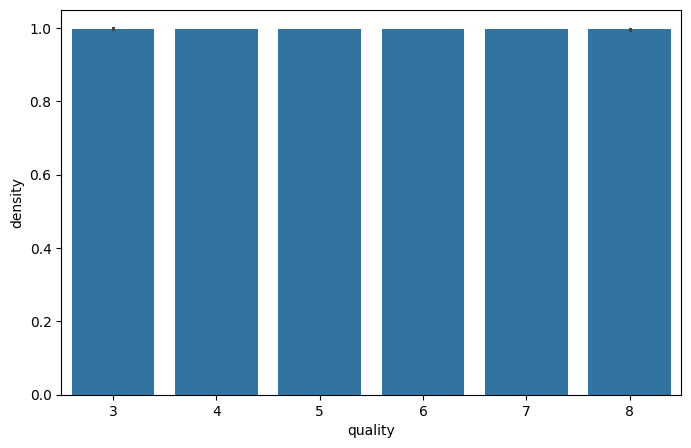

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='quality',
    y='density',
    data=df
)

plt.show()

Convert Quality into Classification

In [ ]:
df['quality'] = np.where(
    df['quality'] >= 7,
    1,
    0
)

Separate Features and Target

In [ ]:
X = df.drop('quality', axis=1)

y = df['quality']

Split Dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Random Forest Classifier

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, rf_pred)
)

Random Forest Accuracy: 0.9344978165938864


SGD Classifier

In [ ]:
sgd = SGDClassifier(
    random_state=42
)

sgd.fit(X_train, y_train)

sgd_pred = sgd.predict(X_test)

print(
    "SGD Accuracy:",
    accuracy_score(y_test, sgd_pred)
)

SGD Accuracy: 0.834061135371179


Support Vector Classifier

In [ ]:
svc = SVC()

svc.fit(X_train, y_train)

svc_pred = svc.predict(X_test)

print(
    "SVC Accuracy:",
    accuracy_score(y_test, svc_pred)
)

SVC Accuracy: 0.8995633187772926


Compare Models

In [ ]:
results = pd.DataFrame({
    "Model":[
        "Random Forest",
        "SGD",
        "SVC"
    ],
    "Accuracy":[
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, sgd_pred),
        accuracy_score(y_test, svc_pred)
    ]
})

print(results)

           Model  Accuracy
0  Random Forest  0.934498
1            SGD  0.834061
2            SVC  0.899563


In [ ]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.95      0.98      0.96       201
           1       0.78      0.64      0.71        28

    accuracy                           0.93       229
   macro avg       0.87      0.81      0.83       229
weighted avg       0.93      0.93      0.93       229

